# 02. Human-In-The-Loop (HITL) - 미들웨어 기반

> Part 02의 그래프 중단/재개 기초를, V1 미들웨어의 **도구 호출 단위 승인 정책**으로 확장합니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `HumanInTheLoopMiddleware`로 에이전트 도구 호출에 사람의 승인을 추가할 수 있어요
2. `interrupt_on` 딕셔너리로 도구별 승인 정책(approve/edit/reject)을 설정할 수 있어요
3. `__interrupt__` 데이터 구조를 파싱하여 대기 중인 작업 정보를 사용자에게 표시할 수 있어요
4. `Command(resume=...)` 패턴으로 interrupt된 에이전트 실행을 재개할 수 있어요
5. 위험도 기반 승인 정책을 설계하고 조건부 승인 로직을 구현할 수 있어요

## 사전 지식

- `02_LangGraph_Basics/08-Human-In-The-Loop.ipynb`: `interrupt_before`, 체크포인터, 중단/재개 흐름
- `02_LangGraph_Basics/09-State-Management.ipynb`: `update_state`, replay, 상태 주입
- 이전 노트북 `01-Middleware-Basics.ipynb`: 미들웨어 훅과 체이닝


## 이 노트북의 HITL 초점

HITL이 필요한 이유와 체크포인터 기반 중단/재개 메커니즘은 Part 02에서 배웠어요. 이 노트북은 같은 개념을 다시 설명하기보다, **도구 이름과 인자 수준에서 승인 정책을 선언하는 방법**을 다룹니다.

| 구분 | Part 02 Graph-level HITL | 이번 노트북 Middleware HITL |
|---|---|---|
| 중단 위치 | 특정 그래프 노드 전/내부 | 모델 응답 후, 도구 실행 직전 |
| 제어 단위 | 그래프 단계 | 도구 이름과 도구 인자 |
| 재개 방식 | `stream(None, config)` 또는 상태 주입 | `Command(resume={"decisions": [...]})` |
| 적합한 상황 | 워크플로우 단계 검토 | 이메일·파일쓰기·SQL 같은 도구 호출 승인 |

> 🔑 **핵심 개념**: `HumanInTheLoopMiddleware`는 HITL을 “어떤 도구를 어떤 정책으로 가로챌지”의 문제로 바꿔줍니다. 그래서 UI 버튼도 approve/edit/reject처럼 도구 호출 단위로 설계할 수 있어요.


## HITL 미들웨어 아키텍처

```mermaid
flowchart TD
    A["사용자 메시지<br/>User Message"] --> B["에이전트<br/>Agent"]
    B --> C["모델 호출<br/>LLM Call"]
    C --> D["after_model 훅<br/>HumanInTheLoopMiddleware"]
    D --> E{"interrupt_on 검사<br/>도구 승인 필요?"}
    E -- "False / 승인 불필요" --> F["도구 실행<br/>Tool Execution"]
    E -- "True / 승인 필요" --> G["__interrupt__ 발생<br/>실행 일시 중지"]
    G --> H["사람의 결정<br/>Human Decision"]
    H -- "approve" --> F
    H -- "edit" --> I["인자 수정<br/>Args Update"]
    H -- "reject" --> J["거부 ToolMessage<br/>Reject Message"]
    H -- "respond" --> K["직접 응답<br/>Human Response"]
    I --> F
    F --> K["최종 응답<br/>Final Response"]
    J --> K

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef interrupt fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef output fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A input
    class B,C,D,F,I process
    class E decision
    class G,H interrupt
    class J,K output
```

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키 읽기)
from dotenv import load_dotenv
import os

load_dotenv()

# LangSmith 추적 활성화 (실행 과정 모니터링)
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Part06-HITL"

# 환경 설정 완료

True

## 1. 기본 HITL 설정

### HumanInTheLoopMiddleware 핵심 파라미터

`HumanInTheLoopMiddleware`를 사용할 때 두 가지를 기억하세요:

1. **`interrupt_on` 딕셔너리**: 어떤 도구를, 어떤 정책으로 가로챌지 설정해요
2. **`checkpointer` 필수**: interrupt 후 상태를 저장하고 같은 `thread_id`로 재개하기 위해 필요해요

| `interrupt_on` 값 | 의미 | 예시 |
|----|------|------|
| `True` | 기본 결정 타입 허용 | `"write_file": True` |
| `{"allowed_decisions": [...]}` | 특정 결정만 허용 | `"execute_sql": {"allowed_decisions": ["approve", "reject"]}` |
| `False` | 승인 없이 자동 실행 | `"read_file": False` |

> ℹ️ **버전 주의**: `respond` 결정 타입은 `langchain>=1.2.18` 계열에서 지원돼요. 현재 실습 환경에서는 `approve`, `edit`, `reject`, `respond`를 모두 사용할 수 있습니다.

> 🔁 **복습 연결**: checkpointer와 `thread_id` 자체는 Part 02의 memory/HITL 단원에서 배운 내용입니다. 여기서는 미들웨어가 그 저장·재개 메커니즘을 도구 승인 정책에 활용하는 방식을 봅니다.
>
> ⚠️ **구분하기**: `interrupt_before`/`interrupt_after`는 그래프의 정적 중단점으로, 디버깅·테스트·중단/재개 메커니즘 학습에 유용해요. 실제 도구 호출 승인 UX는 보통 `interrupt()`가 만든 중단을 `Command(resume=...)`로 재개하는 동적 HITL 패턴이며, `HumanInTheLoopMiddleware`는 이 패턴을 도구 정책으로 감싼 고수준 API예요.


In [2]:
# ---------------------------------------------------
# 필수 임포트 - HITL 미들웨어와 에이전트 구성 요소
# ---------------------------------------------------
from langchain.agents import create_agent                          # V1 에이전트 생성 함수
from langchain.agents.middleware import HumanInTheLoopMiddleware   # HITL 미들웨어
from langgraph.checkpoint.memory import InMemorySaver              # 메모리 내 체크포인터
from langchain.chat_models import init_chat_model                  # V1 모델 초기화
from langchain.tools import tool                                    # 도구 데코레이터
from langgraph.types import Command                                 # 실행 재개 명령
from dotenv import find_dotenv, load_dotenv                         # .env 환경 변수 로드

# .env 파일에서 OPENAI_API_KEY 등을 불러와요
load_dotenv(find_dotenv(usecwd=True), override=True)

# 기본 모델 초기화 (gpt-4o-mini: 비용 효율적, 학생 접근성 높음)
# Anthropic 사용 시: "anthropic:claude-sonnet-4-5"
model = init_chat_model("openai:gpt-4o-mini")

# 임포트 및 모델 초기화 완료

In [3]:
# ---------------------------------------------------
# 파일 관리 도구 정의
# ---------------------------------------------------
# 쓰기/삭제: 되돌리기 어려운 작업 → 승인 필요
# 읽기: 부작용 없는 안전한 작업 → 승인 불필요

@tool
def write_file(filename: str, content: str) -> str:
    """파일에 내용을 작성합니다."""
    with open(filename, "w", encoding="utf-8") as f:
        f.write(content)
    return f"File '{filename}' written successfully"

@tool
def read_file(filename: str) -> str:
    """파일에서 내용을 읽어옵니다."""
    try:
        with open(filename, "r", encoding="utf-8") as f:
            return f.read()
    except FileNotFoundError:
        return f"File '{filename}' not found"

@tool
def delete_file(filename: str) -> str:
    """파일을 삭제합니다."""
    import os
    try:
        os.remove(filename)
        return f"File '{filename}' deleted successfully"
    except FileNotFoundError:
        return f"File '{filename}' not found"

# ---------------------------------------------------
# HITL 미들웨어와 함께 에이전트 생성
# ---------------------------------------------------
agent = create_agent(
    model=model,
    tools=[write_file, read_file, delete_file],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "write_file": True,   # approve/edit/reject/respond 모두 허용
                "delete_file": True,  # approve/edit/reject/respond 모두 허용
                "read_file": False,   # 안전한 작업 - 자동 실행
            },
            description_prefix="파일 작업 승인 대기 중",  # interrupt 설명 접두사
        ),
    ],
    checkpointer=InMemorySaver(),  # 체크포인터 필수 - 상태 저장/복원
)

# HITL 미들웨어가 설정된 에이전트 생성 완료
# - write_file: 승인 필요 (approve/edit/reject/respond)
# - delete_file: 승인 필요 (approve/edit/reject/respond)
# - read_file: 자동 실행 (승인 불필요)

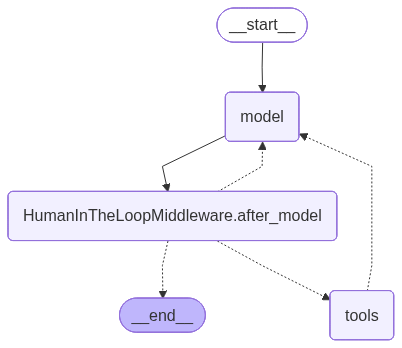

In [4]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: LLM이 도구 호출을 결정하면 HumanInTheLoopMiddleware가 interrupt를 발생시켜요
# tools 노드: 승인된 도구 호출을 실행해요
# 조건부 엣지: tool_call 유무에 따라 tools 또는 END로 분기해요
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## 2. `__interrupt__` 구조 이해하기

에이전트가 승인이 필요한 도구를 호출하면 실행이 일시 중지되고 결과에 `__interrupt__` 키가 포함돼요.

`__interrupt__` 값의 구조를 알아야 사용자에게 적절한 정보를 표시할 수 있어요:

```python
{
    "action_requests": [
        {
            "name": "write_file",           # 도구 이름
            "args": {"filename": ..., ...},   # 전달될 인자
            "description": "..."             # 설명 (description_prefix 포함)
        }
    ],
    "review_configs": [
        {
            "action_name": "write_file",
            "allowed_decisions": ["approve", "edit", "reject", "respond"]
        }
    ]
}
```

> 💡 **실무 팁**: `review_configs`의 `allowed_decisions`를 확인하면 현재 어떤 결정이 가능한지 동적으로 파악할 수 있어요. UI를 만들 때 이 값을 기반으로 버튼을 렌더링하면 돼요.

In [5]:
# ---------------------------------------------------
# 파일 쓰기 요청 → interrupt 발생 확인
# ---------------------------------------------------
# thread_id: 이 대화 세션의 고유 식별자
# 같은 thread_id로 재개해야 interrupt된 상태를 복원할 수 있어요
config = {"configurable": {"thread_id": "file-thread-001"}}

# 에이전트에 파일 쓰기 요청
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "hello_world.txt 파일에 'Hello, LangGraph!'라고 작성해줘"
            }
        ]
    },
    config=config,
)

# interrupt 발생 여부 확인
if "__interrupt__" in result:
    # === Interrupt 감지됨 ===
    interrupt_data = result["__interrupt__"][0].value  # 첫 번째 interrupt의 값
    print(interrupt_data)
    
    # 대기 중인 작업 요청 출력
    # [대기 중인 작업 요청 (action_requests)]
    for i, action in enumerate(interrupt_data["action_requests"]):
        print(f"  [{i}] 도구명: {action['name']}")
        print(f"      인자: {action['args']}")
        print(f"      설명: {action['description']}")

    # 허용된 결정 타입 출력
    # [허용된 결정 타입 (review_configs)]
    for cfg in interrupt_data["review_configs"]:
        print(f"  도구: {cfg['action_name']}")
        print(f"  가능한 결정: {cfg['allowed_decisions']}")
else:
    # Interrupt 없이 실행 완료
    print(result["messages"][-1].content)

{'action_requests': [{'name': 'write_file', 'args': {'filename': 'hello_world.txt', 'content': 'Hello, LangGraph!'}, 'description': "파일 작업 승인 대기 중\n\nTool: write_file\nArgs: {'filename': 'hello_world.txt', 'content': 'Hello, LangGraph!'}"}], 'review_configs': [{'action_name': 'write_file', 'allowed_decisions': ['approve', 'edit', 'reject', 'respond']}]}
  [0] 도구명: write_file
      인자: {'filename': 'hello_world.txt', 'content': 'Hello, LangGraph!'}
      설명: 파일 작업 승인 대기 중

Tool: write_file
Args: {'filename': 'hello_world.txt', 'content': 'Hello, LangGraph!'}
  도구: write_file
  가능한 결정: ['approve', 'edit', 'reject', 'respond']


## 3. 결정 타입별 처리

`HumanInTheLoopMiddleware`의 결정은 도구 호출별로 전달해요. 기본적으로 자주 쓰는 결정은 `approve`, `edit`, `reject`이고, 사람이 도구 실행 대신 직접 응답을 반환해야 할 때는 `respond`를 사용할 수 있어요.

### 3-1. Approve (승인)

`approve`는 에이전트가 제안한 작업을 **수정 없이 그대로 실행**해요. 가장 단순한 형태이고, 인자 변경이 필요 없을 때 사용해요.

> 🎯 **강의 포인트**: `Command(resume={"decisions": [{"type": "approve"}]})` 패턴을 기억해주세요. decisions 리스트의 순서가 action_requests의 순서와 정확히 일치해야 해요.

In [6]:
# ---------------------------------------------------
# approve: 도구 호출을 그대로 승인하고 실행
# ---------------------------------------------------
# Command(resume=...): interrupt된 실행을 재개하는 패턴
# 반드시 동일한 thread_id(config)를 사용해야 해요
result_approved = agent.invoke(
    Command(
        resume={"decisions": [{"type": "approve"}]}  # approve: 그대로 실행
    ),
    config=config,  # 동일한 thread_id - 이전 상태에서 재개
)

# 승인 후 결과:
print(result_approved["messages"][-1].content)

# 파일이 실제로 생성되었는지 확인
import os
if os.path.exists("hello_world.txt"):
    with open("hello_world.txt", "r", encoding="utf-8") as f:
        print(f"\n파일 내용 확인: {f.read()}")

`hello_world.txt` 파일에 'Hello, LangGraph!'가 성공적으로 작성되었습니다.

파일 내용 확인: Hello, LangGraph!


### 3-2. Edit (수정)

`edit`은 도구 호출의 **인자를 수정한 후 실행**해요. 에이전트가 올바른 도구를 선택했지만 세부 사항을 조정해야 할 때 유용해요.

`edited_action` 필드에 수정된 인자를 담은 딕셔너리를 넣으면 돼요:
```python
{
    "type": "edit",
    "edited_action": {
        "name": "write_file",  # 도구 이름 (그대로 유지)
        "args": {              # 수정된 인자
            "filename": "새_파일명.txt",
            "content": "수정된 내용"
        }
    }
}
```

> ⚠️ **자주 하는 실수**: edit 시 수정할 필드만 바꾸고 나머지는 반드시 원래 값을 유지해야 해요. 도구 이름(`name`)을 바꾸면 안 돼요.

In [7]:
# ---------------------------------------------------
# edit: 인자를 수정한 후 실행
# ---------------------------------------------------
# 새 thread_id로 새 대화 시작 (이전 thread와 독립적)
config_edit = {"configurable": {"thread_id": "file-thread-002"}}

# 원본 파일명으로 요청
result_before_edit = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "original.txt 파일에 'Original content'를 작성해줘"
            }
        ]
    },
    config=config_edit,
)

if "__interrupt__" in result_before_edit:
    # Interrupt 감지 - 파일명과 내용을 수정해서 실행할게요
    
    interrupt_data = result_before_edit["__interrupt__"][0].value
    original_action = interrupt_data["action_requests"][0]
    print(f"원본 인자: {original_action['args']}")

    # edit: 파일명과 내용을 수정하여 실행
    result_edited = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "write_file",   # 도구명은 그대로 유지
                            "args": {
                                "filename": "modified.txt",     # 파일명 변경
                                "content": "Modified content"   # 내용 변경
                            }
                        }
                    }
                ]
            }
        ),
        config=config_edit,  # 동일한 thread_id
    )

    # 수정 후 결과:
    print(result_edited["messages"][-1].content)

    # 수정된 파일 확인
    if os.path.exists("modified.txt"):
        with open("modified.txt", "r", encoding="utf-8") as f:
            print(f"\nmodified.txt 파일 내용: {f.read()}")
    
    # 원본 파일은 생성되지 않아야 함
    print(f"original.txt 존재 여부: {os.path.exists('original.txt')}")

원본 인자: {'filename': 'original.txt', 'content': 'Original content'}


modified.txt 파일 내용: Modified content
original.txt 존재 여부: False


### 3-3. Reject (거부)

`reject`는 도구 호출을 **거부하고 에이전트에게 피드백을 제공**해요. 에이전트는 이 피드백을 바탕으로 다른 접근법을 시도하거나 사용자에게 상황을 설명할 수 있어요.

> 💡 **실무 팁**: `message` 필드에 구체적인 거부 사유를 작성하면 에이전트가 더 유익한 대안을 제시해요. 단순히 "거부"보다는 "이유와 권장 사항"을 함께 제공하면 UX가 좋아져요.

> 📌 **출력이 비어 보일 때**: `reject` 직후 `messages[-1].content`가 빈 문자열일 수 있어요. 거부 피드백은 대화에 추가되어 **에이전트 루프로 다시 들어가기** 때문에, 에이전트가 곧바로 텍스트로 답하기보다 **수정된 도구 호출을 다시 제안**하는 경우가 많아요(아래 4절 SQL 예제가 바로 이 동작을 보여줘요). 즉 빈 응답은 버그가 아니라 "에이전트가 다음 행동을 도구 호출로 이어간 상태"라는 신호예요.

In [8]:
# ---------------------------------------------------
# reject: 도구 호출 거부 + 피드백 제공
# ---------------------------------------------------
config_reject = {"configurable": {"thread_id": "file-thread-003"}}

# 파일 삭제 요청
result_before_reject = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "hello_world.txt 파일을 삭제해줘"
            }
        ]
    },
    config=config_reject,
)

if "__interrupt__" in result_before_reject:
    # Interrupt 감지 - 삭제 요청을 거부할게요
    print("Interrupt 감지")
    # reject: 거부 사유와 함께 거부
    result_rejected = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "reject",
                        "message": "이 파일에는 중요한 데이터가 있어요. 삭제 전에 반드시 백업을 먼저 만들어주세요."
                    }
                ]
            }
        ),
        config=config_reject,
    )

    # 거부 후 에이전트의 다음 행동 확인
    # reject의 message는 화면 출력이 아니라 에이전트에게 전달되는 피드백이에요.
    # 피드백을 받은 에이전트는 루프로 다시 들어가서, 텍스트로 답하기보다
    # 수정된 도구 호출(예: 백업용 write_file, 또는 delete_file 재시도)을 제안하는 경우가 많아요.
    # write_file/delete_file은 모두 승인 대상이라, 이 새 호출도 실행 전 다시 interrupt돼요.
    print("\n거부 피드백을 받은 후 에이전트의 다음 행동:")
    if "__interrupt__" in result_rejected:
        # 에이전트가 피드백을 반영해 새 도구 호출을 다시 제안 → 또 승인 대기 상태
        revised = result_rejected["__interrupt__"][0].value
        action = revised["action_requests"][0]
        print(f"다시 제안한 도구: {action['name']}")
        print(f"인자: {action['args']}")
        print("  → 이 호출도 승인 대상이라 실행 전 다시 승인 대기 상태입니다.")
    else:
        # 에이전트가 새 도구 호출 대신 텍스트로 답한 경우
        # (content가 빈 문자열이면, 도구 호출만 있고 텍스트 응답이 없다는 신호예요)
        print(repr(result_rejected["messages"][-1].content))


Interrupt 감지

거부 피드백을 받은 후 에이전트의 다음 행동:
다시 제안한 도구: write_file
인자: {'filename': 'hello_world_backup.txt', 'content': 'hello_world.txt 파일의 데이터 백업입니다.'}
  → 이 호출도 승인 대상이라 실행 전 다시 승인 대기 상태입니다.


### 3-4. Respond (직접 응답)

`respond`는 도구를 실행하지 않고, 사람이 제공한 메시지를 **성공한 도구 결과처럼** 에이전트에게 전달해요. 그래서 삭제·결제 같은 부작용 도구를 거부하는 용도보다는, `ask_user`처럼 사람의 답변 자체가 필요한 도구에 적합해요.

```python
Command(resume={"decisions": [{
    "type": "respond",
    "message": "금요일 오전 10시가 좋습니다."
}]})
```

> ⚠️ **주의**: `respond`의 메시지는 성공한 도구 결과로 취급돼요. 작업을 거부하거나 에이전트에게 재시도를 막는 피드백을 주려면 `reject`를 사용하세요.

> 🎯 **강의 포인트**: `respond`는 사람이 도구 역할을 대신해 값을 제공하고, 그 값을 받은 에이전트가 다음 응답을 이어가게 만드는 결정 타입이에요.


In [9]:
# ---------------------------------------------------
# respond: 사람이 도구 결과를 직접 제공
# ---------------------------------------------------
# respond는 도구를 실행하지 않고, 사람이 작성한 message를 ToolMessage처럼 전달해요.
# 예제에서는 ask_user 도구 실행 대신 사람이 답변을 직접 제공합니다.

@tool
def ask_user(question: str) -> str:
    """사용자에게 확인 질문을 하고 사용자의 답변을 받습니다."""
    return f"사용자에게 질문함: {question}"

respond_agent = create_agent(
    model=model,
    tools=[ask_user],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "ask_user": {"allowed_decisions": ["approve", "respond"]},
            },
            description_prefix="사용자 확인 대기 중",
        ),
    ],
    checkpointer=InMemorySaver(),
)

config_respond = {"configurable": {"thread_id": "respond-thread-001"}}

result_before_respond = respond_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "회의 일정을 확정하기 전에 반드시 ask_user 도구로 사용자에게 선호 시간을 물어봐"
            }
        ]
    },
    config=config_respond,
)

if "__interrupt__" in result_before_respond:
    interrupt_data = result_before_respond["__interrupt__"][0].value
    action = interrupt_data["action_requests"][0]
    review_config = interrupt_data["review_configs"][0]

    print(f"요청된 도구: {action['name']}")
    print(f"요청 인자: {action['args']}")
    print(f"허용된 결정: {review_config['allowed_decisions']}")

    result_responded = respond_agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "respond",
                        "message": "금요일 오전 10시가 좋습니다."
                    }
                ]
            }
        ),
        config=config_respond,
    )

    # respond 메시지를 도구 결과처럼 받은 뒤 에이전트가 이어서 답해요.
    print("\nrespond 후 최종 응답:")
    print(result_responded["messages"][-1].content)
else:
    print(result_before_respond["messages"][-1].content)


요청된 도구: ask_user
요청 인자: {'question': '회의 일정을 확정하기 전에 선호하는 시간을 알려주실 수 있나요?'}
허용된 결정: ['approve', 'respond']

respond 후 최종 응답:
사용자가 선호하는 시간은 금요일 오전 10시입니다. 이 시간에 회의 일정을 확정하시겠습니까?


## 4. 위험도 기반 승인 정책

실제 프로덕션 환경에서는 도구의 위험도에 따라 **다른 승인 정책**을 적용해야 해요.

```
위험도 높음 (SQL, DB 삭제) → approve/reject만 허용 (edit 불허)
위험도 중간 (이메일, 파일) → approve/edit/reject/respond 허용 가능
위험도 낮음 (읽기, 조회)  → 승인 없이 자동 실행
```

> 🔑 **핵심 개념**: SQL 쿼리나 금전 이체는 `edit`을 허용하지 않는 게 좋아요. 임의로 수정된 SQL이나 이체 금액은 원래 요청보다 더 위험할 수 있기 때문이에요.

> 🎯 **강의 포인트**: `interrupt_on` 값으로 `{"allowed_decisions": [...]}` 딕셔너리를 사용하면 결정 타입을 세밀하게 제한할 수 있어요. 이것이 단순히 `True`를 쓰는 것과의 핵심 차이에요.

In [10]:
# ---------------------------------------------------
# 데이터베이스 관리 도구 정의
# ---------------------------------------------------

@tool
def execute_sql(query: str) -> str:
    """데이터베이스에서 SQL 쿼리를 실행합니다."""
    # 실제 환경에서는 데이터베이스에 연결하여 실행해요
    return f"SQL 실행 완료: {query}"

@tool
def read_table(table_name: str, limit: int = 10) -> str:
    """테이블에서 데이터를 조회합니다."""
    return f"{table_name} 테이블에서 {limit}개 행 조회 완료"

@tool
def backup_database(backup_path: str) -> str:
    """데이터베이스 전체를 백업합니다."""
    return f"데이터베이스를 {backup_path}에 백업 완료"

# ---------------------------------------------------
# 위험도 기반 승인 정책 적용
# ---------------------------------------------------
db_agent = create_agent(
    model=model,
    tools=[execute_sql, read_table, backup_database],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                # 위험도 높음: approve/reject만 허용 (edit 불허)
                # SQL 쿼리를 임의로 수정하는 건 더 위험할 수 있어요
                "execute_sql": {"allowed_decisions": ["approve", "reject"]},

                # 위험도 중간: 모든 결정 허용 (백업 경로 수정 가능)
                "backup_database": True,

                # 위험도 낮음: 자동 실행 (조회 작업은 부작용 없음)
                "read_table": False,
            },
            description_prefix="데이터베이스 작업 승인 대기 중",
        ),
    ],
    checkpointer=InMemorySaver(),
)

# 위험도 기반 정책이 적용된 DB 에이전트 생성 완료
# - execute_sql: 위험 (approve/reject만)
# - backup_database: 중간 (approve/edit/reject 모두)
# - read_table: 안전 (자동 실행)

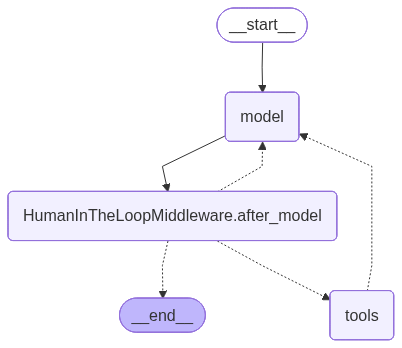

In [11]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: LLM 응답 후 위험도별 HITL 정책이 적용돼요
# execute_sql: approve/reject만 허용 (edit 불가, SQL 수정 위험 방지)
# backup_database: 모든 결정 허용 / read_table: 자동 실행
from IPython.display import Image, display
display(Image(db_agent.get_graph().draw_mermaid_png()))

In [12]:
# ---------------------------------------------------
# 안전한 작업: read_table은 interrupt 없이 바로 실행
# ---------------------------------------------------
config_db_safe = {"configurable": {"thread_id": "db-thread-safe"}}

result_safe = db_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "users 테이블에서 데이터를 조회해줘"
            }
        ]
    },
    config=config_db_safe,
)

# 조회 결과 (interrupt 없음):
print(result_safe["messages"][-1].content)
print(f"\nInterrupt 발생 여부: {'__interrupt__' in result_safe}")

users 테이블에서 10개의 행이 조회되었습니다. 추가로 필요한 정보가 있으면 말씀해 주세요!

Interrupt 발생 여부: False


In [13]:
# ---------------------------------------------------
# 위험한 작업: execute_sql은 interrupt 발생 + approve/reject만 가능
# ---------------------------------------------------
config_db_risky = {"configurable": {"thread_id": "db-thread-risky"}}

result_risky = db_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "30일 이상 된 로그 레코드를 모두 삭제해줘"
            }
        ]
    },
    config=config_db_risky,
)

if "__interrupt__" in result_risky:
    # === SQL 실행 Interrupt 발생 ===
    interrupt_data = result_risky["__interrupt__"][0].value

    action = interrupt_data["action_requests"][0]
    print(f"\nSQL 쿼리: {action['args'].get('query', 'N/A')}")

    # allowed_decisions 확인 - edit이 없어야 함
    review_cfg = interrupt_data["review_configs"][0]
    print(f"허용된 결정: {review_cfg['allowed_decisions']}")
    print(f"  → edit 허용 여부: {'edit' in review_cfg['allowed_decisions']}")

    # 위험한 쿼리이므로 거부
    # message는 사용자 화면 출력이 아니라, 에이전트에게 전달되는 거부 피드백이에요.
    # 여기서는 "어떻게 고치면 되는지"까지 알려줘서 Agent의 다음 행동이 개선되는지 확인해요.
    reject_feedback = (
        "이 DELETE는 너무 광범위합니다. "
        "logs 테이블에서 30일 이상 된 레코드 중 최대 100건만 삭제하는 SQL로 다시 제안해주세요."
    )

    result_after_reject = db_agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "reject",
                        "message": reject_feedback,
                    }
                ]
            }
        ),
        config=config_db_risky,
    )

    # reject 후 Agent가 실제로 어떻게 반응했는지 확인
    print("\n거부 피드백을 받은 후 Agent의 다음 행동:")

    if "__interrupt__" in result_after_reject:
        # Agent가 피드백을 반영해 새 execute_sql 호출을 제안한 경우
        # execute_sql은 여전히 승인 대상이므로, 개선된 SQL도 바로 실행되지 않고 다시 interrupt돼요.
        revised_interrupt_data = result_after_reject["__interrupt__"][0].value
        revised_action = revised_interrupt_data["action_requests"][0]
        revised_args = revised_action.get("args", revised_action.get("arguments", {}))

        print(f"개선된 도구 호출: {revised_action['name']}")
        print(f"개선된 SQL 쿼리: {revised_args.get('query', 'N/A')}")
        print("  → 개선된 쿼리도 execute_sql이므로 실행 전 다시 승인 대기 상태입니다.")
    else:
        # Agent가 새 도구 호출 대신 텍스트로 답한 경우
        print(result_after_reject["messages"][-1].content)



SQL 쿼리: DELETE FROM logs WHERE log_date < NOW() - INTERVAL 30 DAY;
허용된 결정: ['approve', 'reject']
  → edit 허용 여부: False

거부 피드백을 받은 후 Agent의 다음 행동:
개선된 도구 호출: execute_sql
개선된 SQL 쿼리: DELETE FROM logs WHERE log_date < NOW() - INTERVAL 30 DAY LIMIT 100;
  → 개선된 쿼리도 execute_sql이므로 실행 전 다시 승인 대기 상태입니다.


## 5. 다중 작업 동시 승인

에이전트가 여러 도구를 동시에 호출할 경우, `action_requests` 리스트에 여러 항목이 들어와요. 이때 `decisions` 리스트도 **동일한 순서로** 각각의 결정을 제공해야 해요.

```python
# action_requests 순서: [send_email, schedule_meeting]
# decisions도 같은 순서로 제공
decisions=[
    {"type": "approve"},      # send_email에 대한 결정
    {"type": "edit", ...}     # schedule_meeting에 대한 결정
]
```

> ⚠️ **자주 하는 실수**: decisions 리스트의 길이가 action_requests와 다르면 오류가 발생해요. 반드시 1:1 매핑해야 해요.

In [14]:
# ---------------------------------------------------
# 다중 도구 호출 에이전트
# ---------------------------------------------------

@tool
def send_email(recipient: str, subject: str, body: str) -> str:
    """이메일을 전송합니다."""
    return f"이메일 전송 완료 → {recipient}, 제목: '{subject}'"

@tool
def schedule_meeting(participants: list, time: str, location: str = "온라인") -> str:
    """회의를 예약합니다."""
    return f"회의 예약 완료 - {time}, 참석자: {', '.join(participants)}, 장소: {location}"

multi_agent = create_agent(
    model=model,
    tools=[send_email, schedule_meeting],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": True,       # 모든 결정 허용
                "schedule_meeting": True, # 모든 결정 허용
            },
        ),
    ],
    checkpointer=InMemorySaver(),
)

config_multi = {"configurable": {"thread_id": "multi-thread-001"}}

# 두 가지 작업을 동시에 요청
result_multi = multi_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "김철수(kim@example.com)에게 프로젝트 업데이트 이메일을 보내고, 내일 오후 2시에 팀 회의도 잡아줘"
            }
        ]
    },
    config=config_multi,
)

if "__interrupt__" in result_multi:
    # === 여러 작업에 대한 승인 필요 ===
    interrupt_data = result_multi["__interrupt__"][0].value

    # 모든 대기 중인 작업 출력
    print(f"\n총 {len(interrupt_data['action_requests'])}개 작업 대기 중:")
    for i, action in enumerate(interrupt_data["action_requests"]):
        print(f"  [{i}] {action['name']}: {action['args']}")


총 2개 작업 대기 중:
  [0] send_email: {'recipient': 'kim@example.com', 'subject': '프로젝트 업데이트', 'body': '안녕하세요 김철수님,\n\n프로젝트에 대한 최신 업데이트를 공유드립니다. 자세한 내용은 첨부된 문서에서 확인하실 수 있습니다.\n\n감사합니다.\n\n팀 드림'}
  [1] schedule_meeting: {'participants': ['kim@example.com'], 'time': '2023-11-30T14:00:00', 'location': '온라인'}


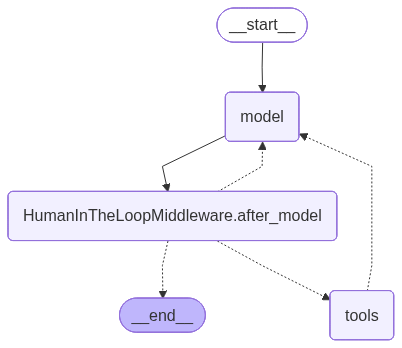

In [15]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: send_email과 schedule_meeting 모두 HITL 승인이 필요해요
# 여러 도구가 동시에 호출되면 action_requests에 복수 항목이 포함돼요
# decisions 리스트로 각 도구에 개별 결정(approve/edit/reject)을 전달해요
from IPython.display import Image, display
display(Image(multi_agent.get_graph().draw_mermaid_png()))

In [16]:
# ---------------------------------------------------
# 다중 결정: 첫 번째 승인, 두 번째 시간 수정 후 승인
# ---------------------------------------------------
# decisions 리스트는 action_requests와 동일한 순서로 작성해요
result_multi_decided = multi_agent.invoke(
    Command(
        resume={
            "decisions": [
                # [0] send_email: 그대로 승인
                {"type": "approve"},

                # [1] schedule_meeting: 시간을 오후 3시로 변경하여 승인
                {
                    "type": "edit",
                    "edited_action": {
                        "name": "schedule_meeting",
                        "args": {
                            "participants": ["김철수", "이영희"],  # 참석자 추가
                            "time": "내일 오후 3시",              # 시간 변경
                            "location": "회의실 A"               # 장소 추가
                        }
                    }
                }
            ]
        }
    ),
    config=config_multi,  # 동일한 thread_id
)

# 최종 결과:
print(result_multi_decided["messages"][-1].content)

김철수님에게 프로젝트 업데이트 이메일을 성공적으로 보냈고, 내일 오후 3시에 팀 회의가 예약되었습니다. 참석자는 김철수와 이영희이며, 장소는 회의실 A입니다.


## 6. 조건부 승인 - 런타임 정책

실제 서비스에서는 interrupt 데이터를 분석해서 **동적으로 승인 여부를 결정**하는 경우가 많아요. 예를 들어:

- 금전 이체: 금액이 한도 이하면 자동 승인, 초과면 거부
- 파일 작업: 특정 디렉토리는 승인, 시스템 디렉토리는 거부
- SQL: 읽기 쿼리는 승인, 쓰기/삭제는 거부

> 💡 **실무 팁**: 조건부 승인 로직을 함수로 분리해두면 정책 변경이 쉬워요. 정책을 설정 파일이나 DB에서 읽어오면 재배포 없이 런타임에 정책을 변경할 수 있어요.

In [17]:
# ---------------------------------------------------
# 금융 도구 정의
# ---------------------------------------------------

@tool
def transfer_money(amount: float, recipient: str, memo: str = "") -> str:
    """수신자에게 금액을 이체합니다."""
    return f"이체 완료: {recipient}에게 {amount:,.0f}원 (메모: {memo})"

@tool
def check_balance(account_id: str) -> str:
    """계좌 잔액을 조회합니다."""
    return f"계좌 {account_id} 잔액: 1,500,000원"

# 금융 에이전트 (이체는 approve/reject만, 조회는 자동 실행)
finance_agent = create_agent(
    model=model,
    tools=[transfer_money, check_balance],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                # 이체: approve/reject만 허용 (금액 조작 방지)
                "transfer_money": {"allowed_decisions": ["approve", "reject"]},
                # 조회: 자동 실행 (부작용 없음)
                "check_balance": False,
            },
            description_prefix="금융 거래 승인 대기 중",
        ),
    ],
    checkpointer=InMemorySaver(),
)

# 금융 에이전트 생성 완료

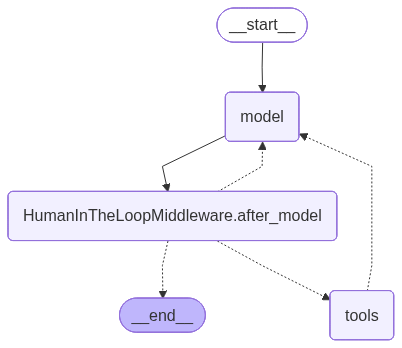

In [18]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: 이체 도구는 approve/reject만 허용 (금액 조작 방지)
# 잔액 조회(check_balance)는 자동 실행 (부작용 없음)
from IPython.display import Image, display
display(Image(finance_agent.get_graph().draw_mermaid_png()))

In [19]:
# ---------------------------------------------------
# 조건부 승인 정책 함수
# ---------------------------------------------------
# 금액 한도 기준으로 자동 승인/거부를 결정해요

TRANSFER_LIMIT = 100_000  # 10만원 이하 자동 승인

def make_transfer_decision(interrupt_data: dict) -> dict:
    """금액 기준으로 이체 승인 여부를 결정하는 정책 함수예요."""
    action = interrupt_data["action_requests"][0]
    amount = action["args"].get("amount", 0)
    recipient = action["args"].get("recipient", "미지정")

    print(f"\n이체 요청 검토:")
    print(f"  수신자: {recipient}")
    print(f"  금액: {amount:,.0f}원")
    print(f"  한도: {TRANSFER_LIMIT:,.0f}원")

    if amount <= TRANSFER_LIMIT:
        #   → 자동 승인 (한도 이내)
        return {"type": "approve"}
    else:
        print(f"  → 자동 거부 (한도 초과: {amount - TRANSFER_LIMIT:,.0f}원 초과)")
        return {
            "type": "reject",
            "message": f"{amount:,.0f}원은 자동 승인 한도({TRANSFER_LIMIT:,.0f}원)를 초과해요. 담당자 승인이 필요합니다."
        }

print(f"조건부 승인 정책 설정 완료 (한도: {TRANSFER_LIMIT:,.0f}원)")

조건부 승인 정책 설정 완료 (한도: 100,000원)


In [20]:
# ---------------------------------------------------
# 케이스 1: 한도 이내 이체 → 자동 승인
# ---------------------------------------------------
config_finance_1 = {"configurable": {"thread_id": "finance-thread-001"}}

result_finance_1 = finance_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "이박사(lee@example.com)에게 50,000원 이체해줘"}
        ]
    },
    config=config_finance_1,
)

if "__interrupt__" in result_finance_1:
    interrupt_data_1 = result_finance_1["__interrupt__"][0].value
    decision_1 = make_transfer_decision(interrupt_data_1)  # 정책 함수 호출

    result_final_1 = finance_agent.invoke(
        Command(resume={"decisions": [decision_1]}),
        config=config_finance_1,
    )
    # 최종 응답:
    print(result_final_1["messages"][-1].content)


이체 요청 검토:
  수신자: lee@example.com
  금액: 50,000원
  한도: 100,000원
이박사(lee@example.com)에게 50,000원이 이체 완료되었습니다.


In [21]:
# ---------------------------------------------------
# 케이스 2: 한도 초과 이체 → 자동 거부
# ---------------------------------------------------
config_finance_2 = {"configurable": {"thread_id": "finance-thread-001"}}

result_finance_2 = finance_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "최사장(choi@example.com)에게 500,000원 이체해줘"}
        ]
    },
    config=config_finance_2,
)

if "__interrupt__" in result_finance_2:
    interrupt_data_2 = result_finance_2["__interrupt__"][0].value
    decision_2 = make_transfer_decision(interrupt_data_2)  # 정책 함수 호출

    result_final_2 = finance_agent.invoke(
        Command(resume={"decisions": [decision_2]}),
        config=config_finance_2,
    )
    # 최종 응답:
    print(result_final_2["messages"][-1].content)


이체 요청 검토:
  수신자: choi@example.com
  금액: 500,000원
  한도: 100,000원
  → 자동 거부 (한도 초과: 400,000원 초과)
최사장(choi@example.com)에게 500,000원을 이체할 수 없습니다. 이체 금액이 자동 승인 한도인 100,000원을 초과합니다. 담당자의 승인이 필요합니다. 어떻게 하시겠습니까?


## 7. 실습 해설: 커스텀 HITL 시나리오 구현

배운 내용을 바탕으로 직접 실습해봐요!

In [22]:
# ============================================================
# 실습 : 쇼핑 에이전트에 HITL을 적용해보세요
#
# 요구사항:
# 1. add_to_cart(product_id, quantity): 장바구니 추가 - 승인 불필요
# 2. place_order(cart_id, payment_method): 주문 확정 - approve/reject만 허용
# 3. cancel_order(order_id, reason): 주문 취소 - 모든 결정 허용
#
# 조건부 승인 정책:
# - 금액이 50,000원 이상인 주문은 자동 거부 (고액 주문 확인 필요)
# - 50,000원 미만인 주문은 자동 승인
#
# 힌트:
# - place_order 도구에서 금액 정보를 포함하도록 설계해요
# - interrupt_data에서 금액을 파싱하는 정책 함수를 만들어요
# 예상 결과: "사과 5개 주문 확정" 요청 시 interrupt 발생, 금액 기준 자동 결정
# ============================================================

@tool
def add_to_cart(product_name: str, quantity: int, price_per_unit: int) -> str:
    """장바구니에 상품을 추가합니다."""
    total = quantity * price_per_unit
    return f"장바구니 추가: {product_name} x{quantity} = {total:,}원"

@tool
def place_order(product_name: str, quantity: int, total_amount: int) -> str:
    """주문을 확정합니다."""
    return f"주문 완료: {product_name} x{quantity}, 결제 금액: {total_amount:,}원"

@tool
def cancel_order(order_id: str, reason: str) -> str:
    """주문을 취소합니다."""
    return f"주문 {order_id} 취소 완료. 사유: {reason}"

# 실습 해설: 쇼핑 에이전트 완성 코드
shopping_agent = create_agent(
    model=model,
    tools=[add_to_cart, place_order, cancel_order],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                # 각 도구에 적절한 정책을 설정해요
                "add_to_cart": False,        # 장바구니 추가: 자동 실행
                "place_order": {"allowed_decisions": ["approve", "reject"]},  # 주문: approve/reject만
                "cancel_order": True,        # 취소: 모든 결정 허용
            },
        ),
    ],
    checkpointer=InMemorySaver(),
)

# 쇼핑 에이전트 생성 완료
# 아래 셀에서 주문 요청을 테스트해요

In [23]:
# 실습 해설: 쇼핑 에이전트를 테스트하고, interrupt 발생 시 조건부 승인 정책을 적용해보세요

ORDER_THRESHOLD = 50000  # 5만원 이상 주문 자동 거부, 미만은 자동 승인

config_shopping = {"configurable": {"thread_id": "shopping-thread-001"}}

# 주문 요청
result_shopping = shopping_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "사과 10개(개당 3,000원)를 주문해줘"}
        ]
    },
    config=config_shopping,
)

if "__interrupt__" in result_shopping:
    interrupt_data = result_shopping["__interrupt__"][0].value
    action = interrupt_data["action_requests"][0]

    print(f"주문 확정 요청: {action['args']}")

    # 실습 해설: 금액 기준 조건부 승인 로직을 구현해보세요
    total_amount = action["args"].get("total_amount", 0)
    if total_amount >= ORDER_THRESHOLD:
        print(f"고액 주문 감지 ({total_amount:,}원) - 거부")
        decision = {
            "type": "reject",
            "message": f"{total_amount:,}원은 {ORDER_THRESHOLD:,}원 이상 고액 주문이에요. 확인 후 재요청해주세요."
        }
    else:
        print(f"일반 주문 ({total_amount:,}원) - 승인")
        decision = {"type": "approve"}

    result_final = shopping_agent.invoke(
        Command(resume={"decisions": [decision]}),
        config=config_shopping,
    )
    # 최종 응답:
    print(result_final["messages"][-1].content)
else:
    # Interrupt 없이 완료:
    print(result_shopping["messages"][-1].content)

주문 확정 요청: {'product_name': '사과', 'quantity': 10, 'total_amount': 30000}
일반 주문 (30,000원) - 승인
사과 10개가 성공적으로 주문되었습니다. 총 결제 금액은 30,000원입니다.


## 8. HITL 모범 사례 요약

### 체크포인터 선택 가이드

```python
# 개발/테스트: 메모리 내 저장 (재시작 시 초기화)
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()

# 프로덕션: PostgreSQL 저장 (영구 보존)
# from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver
# checkpointer = AsyncPostgresSaver.from_conn_string("postgresql://...")
```

> 🔁 **복습 연결**: `thread_id`와 checkpointer의 기본 원리는 `02_LangGraph_Basics/07-Memory-Checkpointer.ipynb`의 소유 내용입니다. 이 섹션에서는 HITL 미들웨어를 안전하게 운영하기 위한 최소 체크리스트만 정리합니다.

### 권장 승인 정책 패턴

| 도구 유형 | 정책 | 이유 |
|----------|------|------|
| DB 쓰기/삭제 | `{"allowed_decisions": ["approve", "reject"]}` | 임의 edit가 더 위험할 수 있음 |
| 이메일/파일 쓰기 | `True` 또는 `{"allowed_decisions": ["approve", "edit", "reject", "respond"]}` | 사람이 인자를 수정하거나 직접 응답할 수 있으면 UX가 좋음 |
| 읽기/검색 | `False` | 낮은 위험도, 자동 실행 가능 |

> ⚠️ **운영 주의**: interrupt 후 재개는 반드시 같은 `thread_id`와 같은 checkpointer 백엔드를 사용해야 해요.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **역할 분리**: Part 02는 graph-level 중단/재개, 이 노트북은 tool-call-level 승인 정책을 다뤄요
- **`HumanInTheLoopMiddleware`**: `after_model` 훅 기반으로 도구 호출을 가로채고 사람의 승인을 요청하는 미들웨어예요
- **`interrupt_on` 딕셔너리**: `True`, `{"allowed_decisions": [...]}`, `False`로 도구별 정책을 설정해요
- **`__interrupt__` 구조**: `action_requests`와 `review_configs`를 포함해 UI 렌더링에 필요한 정보를 제공합니다
- **결정 타입**: `approve`, `edit`, `reject`, `respond`를 도구 호출별로 전달해요
- **`Command(resume=...)`**: interrupt된 실행을 재개하는 패턴이며, 반드시 동일한 `thread_id`를 사용해요


## 다음 노트북 예고

다음 `03-Context-Engineering.ipynb`에서는 **컨텍스트 엔지니어링(Context Engineering)**을 배워요. Model Context, Tool Context, Life-cycle Context를 조합하여 에이전트에게 올바른 정보를 올바른 시점에 제공하는 방법을 살펴볼 거예요.